# K-plus proches voisins (K-NN)

<img src="./figures/knn.jpg" width="700px"/>

<div class="alert alert-block alert-info">
    
Soit un **train set** composé de $N$ observations:

$$
S_{\rm train} = \left\{ \left( \boldsymbol{x_1}, y_1 \right), \dots, \left( \boldsymbol{x_N}, y_N \right) \right\}.
$$

La matrice des **features** $\boldsymbol{X}$ et le vecteur (ou matrice) des **targets** $\boldsymbol{y}$ sont définis de la manière suivante:

$$
\boldsymbol{X} =
\begin{pmatrix}
\boldsymbol{x_1}^T \\
\vdots \\
1\boldsymbol{x_N}^T 
\end{pmatrix}
=
\begin{pmatrix}
x_{11} & \cdots & x_{1p} \\
\vdots & \ddots & \vdots \\
x_{N1} &\cdots & x_{Np}
\end{pmatrix}~
\text{  et  }~
\boldsymbol{y} =
\begin{pmatrix}
y_1 \\
\vdots \\
y_N 
\end{pmatrix}
$$


L'algorrithme des **K plus proches voisins** ou **K-Nearest Neighbors (KNN)** est le suivant:
    
<img src="./figures/knn_algo.jpg" width="700px"/>
    
</div>

## Exercice


### Generate data
1. Le code de cette section génère des data appartenant à 3 classes différentes.<br>
   Les cluster sont relativement séparés et devraient pouvoir être prédits de manière acceptable grâce à l'algorithme des **K plus proches voisins** ou **K-Nearest Neighbors**.<br>
   Comprenez ce code...
   
   
### Model
2. Compétez la méthode `fit(...)` qui, étant donné un ensemble de points `X_train, y_train` (**features** et **targets**), assigne simplement `X` et `y` comme des attributs de la classe. Ainsi, ces éléments peuvent être récupérés et utilisés dans des méthodes suivantes.


3. Compétez la méthode `_get_distances_and_targets(...)` qui, étant donné un point `x_new`, calcule les distances et les targets des $k$ points de `X` qui sont les plus proches de lui. La documentation de la méthode donne plus de détails.<br>
   Si besoin, la fonction `sorted(dist_and_targets, key = lambda x : x[0])` trie une liste de tuples en fonction de leurs premiers éléments...


4. Compétez la méthode `predict(...)` qui, étant donné un point `x_new`, calcule la prédiction `y_new_hat` associée à ce point. La documentation de la méthode donne plus de détails.<br>
    - En **mode classifieur**, la prédiction `y_new_hat` correspond à la target qui apparaît le plus fréquement parmi les $K$ plus proches voisins.
    Si besoin, la fonction `Counter(targets).most_common()[0][0]` permet d'extraire la target qui apparaît le plus souvent dans la liste `targets`...
    - En **mode régresseur**, la prédiction `y_new_hat` correspond à la moyenne des targets des $K$ plus proches voisins.


5. Instanciez un KNN avec $K=5$ et effectuez quelques prédictions sur des points de votre choix.

### Results
4. - Instanciez un KNN avec $K=5$;
   - Créez un ensemble de points `points` qui couvrent bien tout votre espace $X_1 \times X_2$.<br>
   Si besoin, vous pouvez utiliser les instructions
   ```
   np.linspace(x1_min, x1_max, num=50)
   np.linspace(x2_min, x2_max, num=50)
   ```
   avec `x1_min, x1_max, x2_min, x2_max` appropriés.
   - Calculez les prédictions associées à tous ces points.
   - Faites le graphes des prédictions de tous ces points. Les points qui sont prédits comme classe 1, classe 2 et classe 3 seront représentés de différentes couleurs. Vous devrez voir apparaître des régions colorées correspondant aux zones de décision de votre classifieur.


5. Répétez l'opération avec des KNN pour $K=1$ et $K=200$. Que remarquez-vous?

### Generalization

6. Générez des data de dimension $20$ avec $5$ classes différentes (fonction `make_blobs`).<br>
Visualiizez vos point en dimension $2$ grâce à l'algorithme t-SNE:<br>
https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html<br>
Puis générez un point aléatoire de dimension $20$ (`np.random.normal(...)`), prédisez sa class grâce à votre algorithme KNN, et enfin visualisez les data et votre point à nouveau par le biais de l'algorithme t-SNE.

## Libraries

In [1]:
from collections import Counter

import pandas as pd
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

import seaborn as sns
from matplotlib import pyplot as plt

%matplotlib inline
sns.set_theme()

## Generate data

In [21]:
# generate data
X, y = make_blobs(n_samples=500, n_features=2, centers=3, cluster_std=4.0, random_state=42)

In [22]:
X.shape, y.shape

((500, 2), (500,))

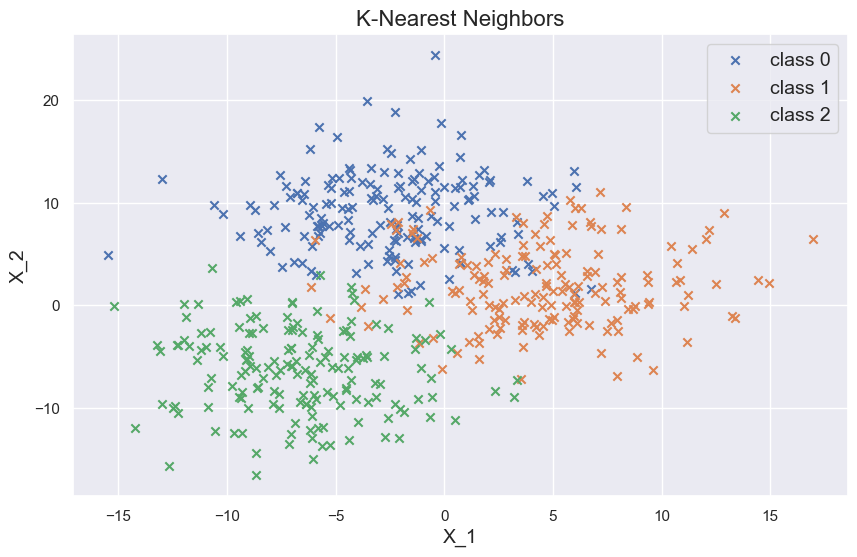

In [23]:
# plot data
plt.figure(figsize=(10, 6))

plt.scatter(X[y==0][:, 0], X[y==0][:, 1], marker = 'x', label="class 0")
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], marker = 'x', label="class 1")
plt.scatter(X[y==2][:, 0], X[y==2][:, 1], marker = 'x', label="class 2")
plt.xlabel("X_1", fontsize=14)
plt.ylabel("X_2", fontsize=14)
plt.legend(fontsize=14)
plt.title("K-Nearest Neighbors", fontsize=16)

# plt.savefig("knn.jpg")
plt.show()

## Model

In [24]:
class KNN():
    """
    Implements the K-Nearest Neighbors (K-NN) algorithm.
    """
    
    def __init__(self, k=1, mode="classification"):
        """
        Constructor.
        
        Parameters
        ----------
        
        k : int
            Number of neighbors.
        mode : str
            Either "classification" or "regression"
        """
        
        self.k = k
        self.mode = mode
        
        
    
    def fit(self, X, y):
        """
        Set the points X and their targets y as attributes of the class.
        In this way, X and y can be used in further methods.
        
        Parameters
        ----------
        X : ndarray
            Initial points of dim N x p.
        y : ndarray
            Targets of the initial points of dim N or (N x p').
        
        """
        # à compléter...
        self.X = X
        self.y = y
    
    
    def _get_distances_and_targets(self, x_new):
        """
        Given a new point, this function computes the distances and targets
        between the new point x_new and the points of X.
        The distances and targets are stored in a list of the form:
        
        dist_and_targets = [[d1, t1], [d2, t2], [d3, t3], ...
        
        where:
        - di is the distance between x_new and the i-th point of X;
        - t1 is the target of the i-th point of X.
        
        Afterwards, the pairs of dist_and_targets is sorted according 
        to their first elements and the k first elements selected.
        The distances of the k first elements of dist_and_targets
        form the list of distances to be returned.
        The targets of the k first elements of dist_and_targets
        form the list of targets to be returned.
        
        
        Parameters
        ----------
            New point of dim p to be classified by the K-NN algo.
            
        Returns
        -------
        dist, targets : list, list
            list of distances and list of targets associated with
            x_new and the initial points X.
            Cf. above documentation for further details.
        """
        
        # à compléter...
        dist_and_targets= []
        for xi, yi in zip(self.X , self.y):    #zip permet de regrouper des éléments de différentes séquences en un objet ex : l1=['a'] , l2[0]  zip(l1,l2)  OUTPUT :  [('a'0)]
            di = xi - x_new
            di = np.linalg.norm(di)
            dist_and_targets.append([di,yi])

        dist_and_targets= sorted(dist_and_targets , key = lambda x : x[0])[0:self.k] # Va retourner que le nombre de voisins fixés
        
        return dist_and_targets
      
        
    def predict(self, x_new):
        """
        Computes the predictions associated to a new point x_new.
        The predictions are computed as follows:
        - compute the distances and targets between x_new and X using
          the method get_distances_and_targets.
        - In the classification mode, return the most common target 
          of this array of k elements.
        - In the regression mode, return the mean of the targets 
          of this array of k elements.
        
        Parameters
        ----------
        x_new : Union[ndarray, list]
            New point of dim p to be classified by the KNN algo.
            
        Returns
        -------
        y_new_hat : Union[int, float]
            Prediction for the point x_new (class or value).
        """
        
        # à compléter...
        l = self._get_distances_and_targets(x_new)
        new_l = [x[1] for x in l]
        counter = Counter(new_l)
        c_hat = counter.most_common()[0][0] # Classe à prédire
        return int(c_hat)
       


## Results

In [26]:
model = KNN(k=7)
model.fit(X,y)
print(model._get_distances_and_targets([-6,-10]))


[[np.float64(0.16506549708437962), np.int64(2)], [np.float64(0.47217575224189035), np.int64(2)], [np.float64(0.5398226479803643), np.int64(2)], [np.float64(0.7994156630667564), np.int64(2)], [np.float64(0.8331824654020128), np.int64(2)], [np.float64(0.8688486718513193), np.int64(2)], [np.float64(1.2049288480245801), np.int64(2)]]


In [33]:
x_test = [10,10]
total_predict = model.predict(x_test)
model.predict(x_test)
total_predict

1

In [29]:
total_predict = [model.predict(x_new) for x_new in X]

## Generalization

In [30]:
X

array([[-2.28253389e+00, -9.69281529e+00],
       [-6.14766774e+00,  1.75599022e+00],
       [ 1.33990906e+01, -1.26002346e+00],
       [-4.07763024e+00,  3.16022634e+00],
       [ 9.44473452e+00,  3.40868192e-01],
       [ 7.96122210e+00, -1.45116562e+00],
       [ 3.36071096e+00, -7.26434919e+00],
       [ 5.72170614e+00,  1.77221725e+00],
       [ 3.69397119e-01,  1.40365174e+00],
       [-9.37890150e+00, -6.77574539e+00],
       [ 2.05358730e+00, -2.35302233e+00],
       [ 2.12518469e+00,  5.73155685e+00],
       [ 6.02293588e+00,  1.20593493e+00],
       [-2.25635580e-01,  1.35565487e+01],
       [ 5.79897826e+00,  1.02747729e+01],
       [ 8.87357678e+00, -5.06178826e+00],
       [-2.79723811e+00,  1.30284177e+01],
       [-1.13705153e+01, -5.35047061e+00],
       [-6.55049123e+00, -2.61818809e+00],
       [-6.93453752e+00,  4.22945963e+00],
       [-9.54391459e-01,  4.22504663e+00],
       [-1.67374324e+00,  1.17560563e+00],
       [ 6.94610669e+00,  3.21817030e+00],
       [-6.

In [11]:
total_predict

[2,
 2,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 2,
 2,
 0,
 0,
 0,
 1,
 2,
 2,
 1,
 1,
 2,
 2,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 2,
 2,
 0,
 2,
 2,
 1,
 0,
 0,
 2,
 1,
 2,
 2,
 0,
 1,
 2,
 1,
 2,
 1,
 2,
 0,
 1,
 1,
 1,
 1,
 2,
 0,
 2,
 1,
 1,
 0,
 0,
 2,
 0,
 1,
 0,
 2,
 2,
 2,
 2,
 1,
 0,
 2,
 1,
 0,
 1,
 1,
 2,
 0,
 0,
 0,
 2,
 1,
 0,
 1,
 2,
 2,
 0,
 0,
 2,
 0,
 2,
 2,
 2,
 0,
 2,
 2,
 0,
 0,
 2,
 1,
 2,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 2,
 2,
 2,
 1,
 1,
 2,
 1,
 2,
 2,
 2,
 1,
 0,
 2,
 2,
 1,
 1,
 2,
 2,
 2,
 0,
 0,
 0,
 1,
 2,
 1,
 0,
 0,
 2,
 0,
 2,
 1,
 1,
 2,
 2,
 0,
 0,
 2,
 0,
 0,
 1,
 2,
 2,
 2,
 0,
 0,
 2,
 2,
 0,
 0,
 0,
 1,
 1,
 0,
 2,
 1,
 0,
 2,
 2,
 0,
 1,
 0,
 2,
 2,
 2,
 2,
 2,
 0,
 1,
 0,
 0,
 2,
 1,
 0,
 1,
 2,
 2,
 1,
 2,
 2,
 0,
 0,
 2,
 2,
 1,
 2,
 0,
 0,
 2,
 0,
 2,
 0,
 1,
 0,
 0,
 2,
 0,
 1,
 0,
 0,
 2,
 1,
 1,
 1,
 1,
 0,
 2,
 2,
 2,
 0,
 1,
 0,
 1,
 1,
 2,
 0,
 0,
 2,
 2,
 1,
 0,
 0,
 1,


In [12]:
nb_error = total_predict != model.y


In [13]:
nb_error
sum = np.sum(nb_error)
pourcent = sum / len(nb_error) *100

In [14]:
pourcent

np.float64(7.199999999999999)

In [50]:
X, y = make_blobs(n_samples=500, n_features=2, centers=3, cluster_std=4.0, random_state=42)

In [51]:
X

array([[-2.28253389e+00, -9.69281529e+00],
       [-6.14766774e+00,  1.75599022e+00],
       [ 1.33990906e+01, -1.26002346e+00],
       [-4.07763024e+00,  3.16022634e+00],
       [ 9.44473452e+00,  3.40868192e-01],
       [ 7.96122210e+00, -1.45116562e+00],
       [ 3.36071096e+00, -7.26434919e+00],
       [ 5.72170614e+00,  1.77221725e+00],
       [ 3.69397119e-01,  1.40365174e+00],
       [-9.37890150e+00, -6.77574539e+00],
       [ 2.05358730e+00, -2.35302233e+00],
       [ 2.12518469e+00,  5.73155685e+00],
       [ 6.02293588e+00,  1.20593493e+00],
       [-2.25635580e-01,  1.35565487e+01],
       [ 5.79897826e+00,  1.02747729e+01],
       [ 8.87357678e+00, -5.06178826e+00],
       [-2.79723811e+00,  1.30284177e+01],
       [-1.13705153e+01, -5.35047061e+00],
       [-6.55049123e+00, -2.61818809e+00],
       [-6.93453752e+00,  4.22945963e+00],
       [-9.54391459e-01,  4.22504663e+00],
       [-1.67374324e+00,  1.17560563e+00],
       [ 6.94610669e+00,  3.21817030e+00],
       [-6.

In [52]:
model = KNN(k=7)
model.fit(X,y)
print(model._get_distances_and_targets([-6,-10]))

[[np.float64(0.16506549708437962), np.int64(2)], [np.float64(0.47217575224189035), np.int64(2)], [np.float64(0.5398226479803643), np.int64(2)], [np.float64(0.7994156630667564), np.int64(2)], [np.float64(0.8331824654020128), np.int64(2)], [np.float64(0.8688486718513193), np.int64(2)], [np.float64(1.2049288480245801), np.int64(2)]]


In [53]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X)
X_embedded

array([[-2.44887848e+01, -6.09525070e+01],
       [-3.89203224e+01, -1.45297251e+01],
       [ 1.08054030e+00, -2.60843830e+01],
       [-4.23833046e+01, -3.21427879e+01],
       [ 7.70054913e+00, -2.20666733e+01],
       [ 1.81524448e+01, -2.91243343e+01],
       [-5.05968056e+01,  6.68932571e+01],
       [ 2.35795193e+01, -6.14567041e+00],
       [ 6.17647324e+01, -7.75193548e+00],
       [ 3.64911041e+01, -5.67323189e+01],
       [-4.43267822e+01,  4.17231979e+01],
       [-1.40225992e+01,  1.96335812e+01],
       [ 2.33706932e+01, -1.01136513e+01],
       [ 1.74779835e+01,  6.48261108e+01],
       [-1.98325920e+01,  6.39879265e+01],
       [ 9.34479427e+00, -3.44689674e+01],
       [ 2.72741375e+01,  5.88205185e+01],
       [ 5.87710915e+01, -4.12536354e+01],
       [-6.32066574e+01, -3.05314660e+00],
       [-3.43298302e+01, -1.12743778e+01],
       [-3.41737099e+01, -2.95850811e+01],
       [-5.01061897e+01, -4.46923676e+01],
       [ 3.30278111e+00,  7.86978602e-01],
       [-5.

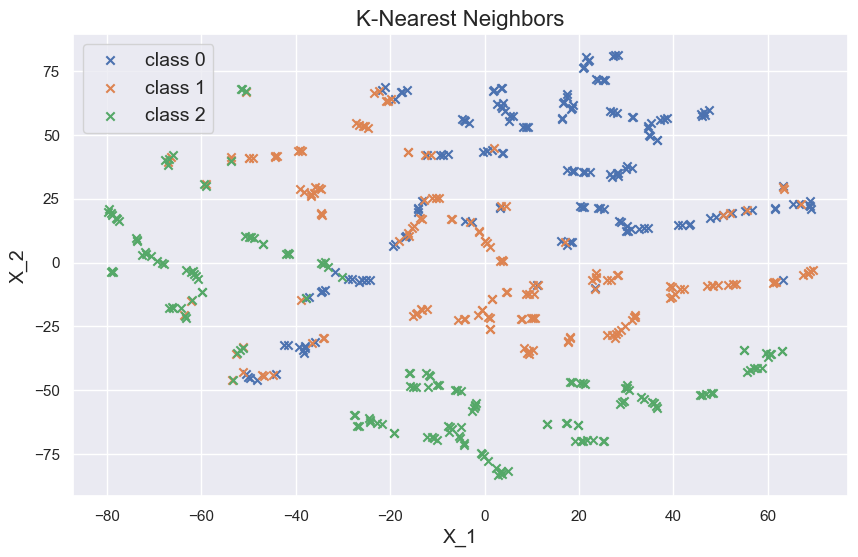

In [54]:
# plot data
plt.figure(figsize=(10, 6))

plt.scatter(X_embedded[y==0][:, 0], X_embedded[y==0][:, 1], marker = 'x', label="class 0")
plt.scatter(X_embedded[y==1][:, 0], X_embedded[y==1][:, 1], marker = 'x', label="class 1")
plt.scatter(X_embedded[y==2][:, 0], X_embedded[y==2][:, 1], marker = 'x', label="class 2")
plt.xlabel("X_1", fontsize=14)
plt.ylabel("X_2", fontsize=14)
plt.legend(fontsize=14)
plt.title("K-Nearest Neighbors", fontsize=16)

# plt.savefig("knn.jpg")
plt.show()